## Decision Tree (Дерево рішень)
метод класифікації та регресії в ML. 

Основні етапи побудови дерева рішень

1. Вибір ознаки яка найкраще розділить дані
2. Визначення порогу для обраної ознаки, за яким дані розподіляються на дві групи.
3. Створення нових вузлів рекурсивно для кожної групи даних.
4. Зупинка рекурсії коли досягнуто критерій зупинки (max-depth)

**Hyperparams:**
- max_depth
- min_samples_leaf
- min_samples_split
- criterion (Функція для вимірювання якості розділення: gini or entropy)

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn import tree
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data = datasets.load_breast_cancer()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [23]:
c_df = pd.DataFrame(data.data, columns=data.feature_names)
c_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type =='minmax':
        scaler = MinMaxScaler()
    elif scaler_type =='std':
        scaler = StandardScaler()
    elif scaler_type =='norm':
        scaler = Normalizer()
    else:
        print("Scaler type definition error")
        return None
    scaler.fit(data)
    res = scaler.transform(data)
    return res

scaled_data =  data_scale(c_df, 'std')
df_scaled = pd.DataFrame(data=scaled_data, columns = c_df.columns)
df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [32]:
X, y = df_scaled, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [33]:
cl_tree = DecisionTreeClassifier(max_depth=10, random_state=3)
cl_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=3)

In [39]:
# Визначаємо точність валідатора за допомогою cross-validation
def cross_val_test(model, dataX, dataY, model_type = "regression", folds = 5):
    cv = KFold(n_splits=folds, shuffle=True)

    if model_type == "regression":
        scorer = {
            'r2': make_scorer(r2_score),
            'mae':make_scorer(mean_absolute_error),
            'mse':make_scorer(mean_squared_error),
            'mape':make_scorer(mean_absolute_percentage_error)
        }
    if model_type == 'classification':
        scorer = {'f1': make_scorer(f1_score)}
    
    scores = cross_validate(model, dataX, dataY)
    return scores

In [ ]:
cross_val_test(cl_tree, X, y,model_type="classification")

'''
fit_time - час навчання моделі для кожного fold (перший повільніший: кешування, init)
score_time - час, який модель витратила на prediction та обчислення метрики (accuracy)
test_score - array of accuracy for 5 folds
'''

{'fit_time': array([0.01420212, 0.00537682, 0.00533199, 0.00544691, 0.00563693]),
 'score_time': array([0.00494432, 0.00058699, 0.0005641 , 0.00056195, 0.00054407]),
 'test_score': array([0.9122807 , 0.93859649, 0.92982456, 0.93859649, 0.88495575])}

In [44]:
list(df_scaled.columns)

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

In [47]:
# Будуємо дерево розв'язків в текстовому поданні.
text_representation = tree.export_text(cl_tree)
print(text_representation)

|--- feature_20 <= 0.11
|   |--- feature_27 <= 0.32
|   |   |--- feature_12 <= 1.85
|   |   |   |--- feature_23 <= -0.17
|   |   |   |   |--- feature_21 <= 1.25
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_21 >  1.25
|   |   |   |   |   |--- feature_21 <= 1.32
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_21 >  1.32
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- feature_23 >  -0.17
|   |   |   |   |--- feature_20 <= -0.01
|   |   |   |   |   |--- feature_1 <= -0.02
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_1 >  -0.02
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_20 >  -0.01
|   |   |   |   |   |--- class: 1
|   |   |--- feature_12 >  1.85
|   |   |   |--- class: 0
|   |--- feature_27 >  0.32
|   |   |--- feature_21 <= -0.32
|   |   |   |--- feature_23 <= -0.12
|   |   |   |   |--- class: 1
|   |   |   |--- feature_23 >  -0.12
|   |   |   |   |--- feature_12 <= -0.12
|   |   |   |   |   

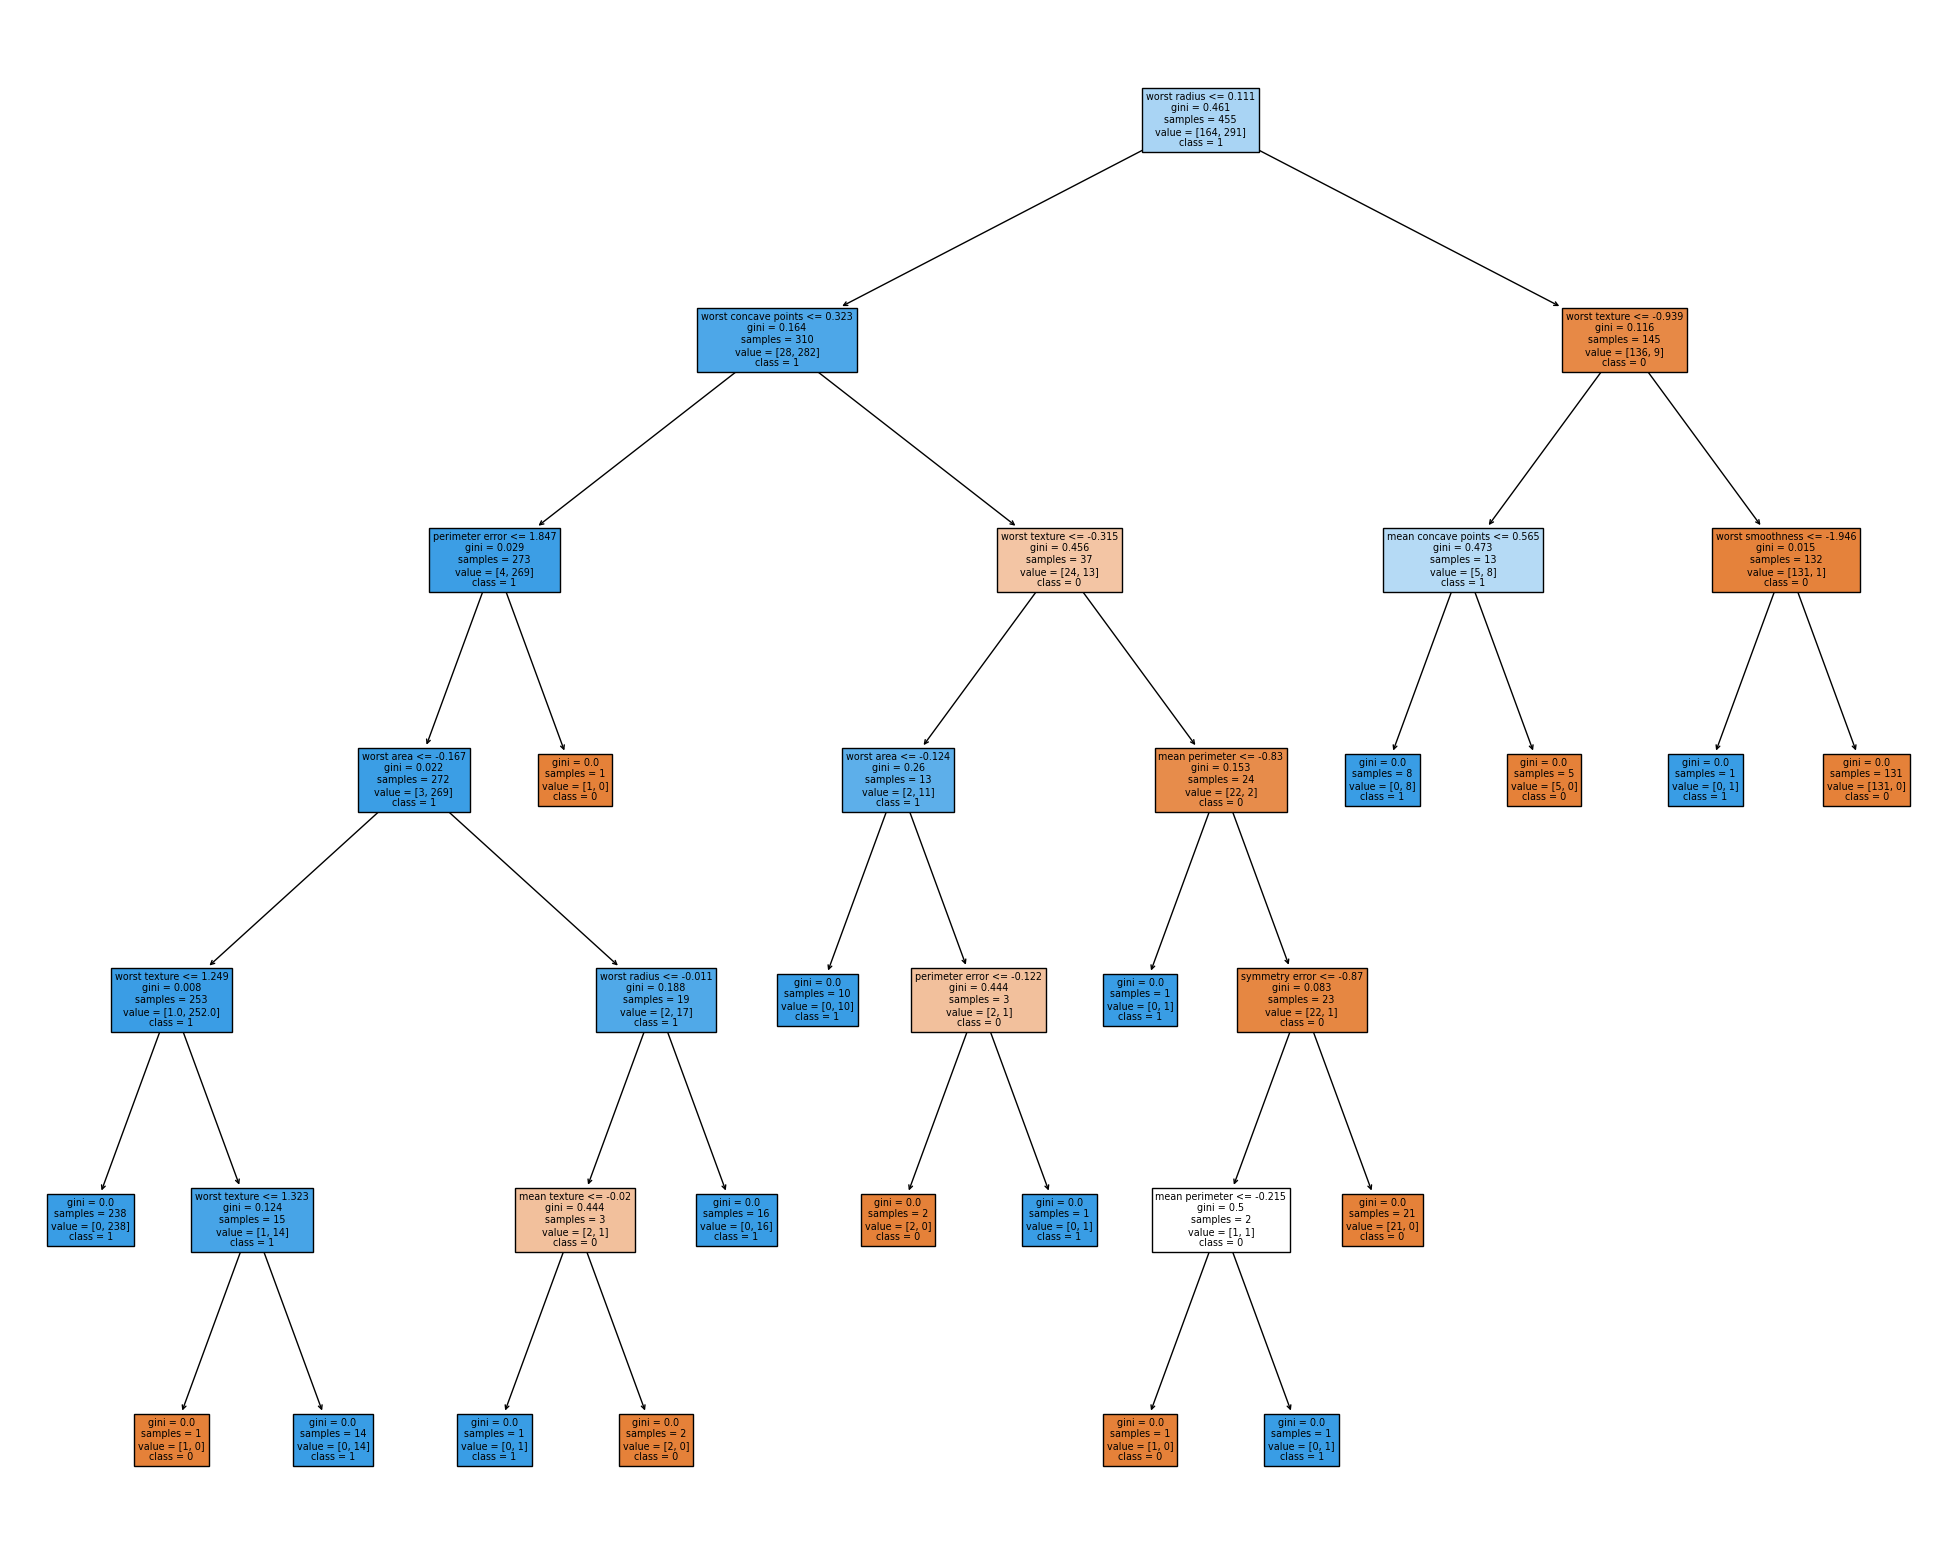

In [52]:
# Visual of decision tree
plt.figure(figsize=(25,20))
tree.plot_tree(
    cl_tree,
    feature_names=list(data.feature_names),
    class_names=['0','1'],
    filled=True
)
plt.show()

worst radius <= 0.111 — умова розбиття => worst_concave points => perimeter error => worst texture ...

gini = 0 означає, що всі зразки в цьому вузлі належать до одного класу, чим більше gini, тим сильніше змішані класи.

value = [n_class0, n_class1] — скільки прикладів кожного класу тут є.

 ### Візуалізації границі прийняття рішення на площині (2 feat)

In [53]:
from sklearn.inspection import DecisionBoundaryDisplay

In [57]:
# в новому datafram поєднуєм ознаки та цільову змінну
df_target = pd.DataFrame(data['target'], columns=['cancer'])
df_target

,cancer
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [64]:
data_cols = list(data.feature_names)
data_cols.append('cancer')
# df_bc - breast cancer dataframe, який містить стандартизовані ознаки та цільову змінну
df_bc = pd.concat([df_scaled, df_target], axis=1) # axis=1 - поєднуємо по стовпцях, axis=0 - поєднуємо по рядках
df_bc.columns = data_cols # присвоюємо нові назви стовпців
df_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,cancer
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


In [ ]:
# X_train_cols нова таблиця з 2 ознаками (з таблиці X беруться тільки 2 стовпці X[[]])
X_train_cols = X[['worst radius', 'texture error']]

# Creating and fitting tree classifier
model = DecisionTreeClassifier(max_depth=4, random_state=1).fit(X_train_cols, y)

'\nякщо точка лежить у зоні свого класу — модель вгадала добре\nякщо точка лежить у зоні іншого класу — модель помилилася\n'

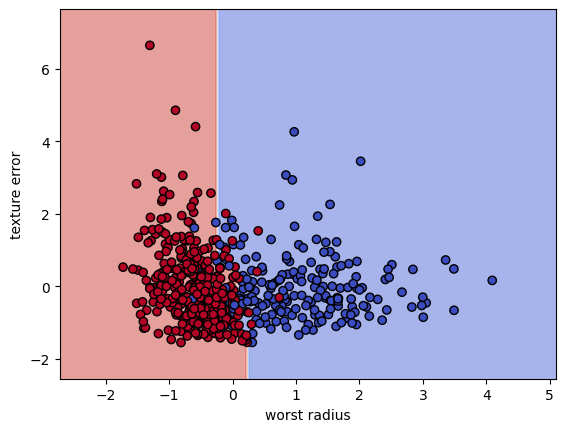

In [85]:
# Plotting tree boundaries
disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_train_cols,
    response_method='predict',
    xlabel='worst radius',
    ylabel='texture error',
    alpha=0.5,
    cmap=plt.cm.coolwarm
)
disp.ax_.scatter(
    df_bc["worst radius"], df_bc["texture error"],
    c=df_bc['cancer'], edgecolors='k',
    cmap=plt.cm.coolwarm
)

'''
якщо точка лежить у зоні свого класу — модель вгадала добре
якщо точка лежить у зоні іншого класу — модель помилилася
'''

## Випадковий ліс (Random Forest)
ансамблевий метод, об'єднання кількох дерев рішень для отримання більш стійкого та ефективного класифікатора чи регресора (випадковим чином вибирати піднабори ознак для навчання)

Основні етапи створення випадкового лісу

1. Випадковий вибір піднаборів ознак:
2. Навчання дерев рішень на кожному піднаборі
3. Об'єднання результатів у випадковому лісі

**Hyperparams:**
- n_estimators (к-сть дерев)
- max_depth
- min_samples_leaf
- min_samples_split (к-сть прикладів, для розділення внутрішнього вузла у кожному дереві)
- max_features (к-сть ознак, для розділення кожного внутрішнього вузла у кожному дереві)

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
cl_rf = RandomForestClassifier(max_depth=2, random_state=3)
cl_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=3)

In [ ]:
# Визначаємо точність за допомогою Cross-Validation
cross_val_test(cl_rf, X, y, 'classification')

'''

'''

{'fit_time': array([0.08240294, 0.14107394, 0.08182406, 0.06511426, 0.06516385]),
 'score_time': array([0.0030539 , 0.00248599, 0.00330591, 0.00232887, 0.00259113]),
 'test_score': array([0.9122807 , 0.93859649, 0.97368421, 0.94736842, 0.95575221])}

In [76]:
# Experiment 1
cl_rf1 = RandomForestClassifier(n_estimators=5, max_depth=5)
cl_tree1 = DecisionTreeClassifier(max_depth=10)

In [77]:
cross_val_test(cl_rf1, X, y, model_type='classification')

{'fit_time': array([0.01726794, 0.01113987, 0.00683069, 0.00594592, 0.00580883]),
 'score_time': array([0.00386   , 0.00110722, 0.00095725, 0.00079918, 0.00135231]),
 'test_score': array([0.92982456, 0.95614035, 0.97368421, 0.95614035, 0.94690265])}

In [78]:
cross_val_test(cl_tree1, X, y, model_type='classification')

{'fit_time': array([0.0052259 , 0.00661302, 0.005687  , 0.00663304, 0.00613117]),
 'score_time': array([0.00087905, 0.00094509, 0.00118208, 0.00156999, 0.00086999]),
 'test_score': array([0.9122807 , 0.90350877, 0.90350877, 0.94736842, 0.91150442])}

In [80]:
# Experiment 2
cl_rf2 = RandomForestClassifier(n_estimators=10, max_depth=5)
cl_tree2 = DecisionTreeClassifier(max_depth=30)

In [82]:
cross_val_test(cl_rf2, X, y, model_type='classification')

{'fit_time': array([0.02487612, 0.01162696, 0.01059604, 0.00962305, 0.00961709]),
 'score_time': array([0.00140595, 0.00121665, 0.00091481, 0.00081801, 0.00093603]),
 'test_score': array([0.90350877, 0.94736842, 0.98245614, 0.96491228, 0.97345133])}

In [83]:
cross_val_test(cl_tree2, X, y, model_type='classification')

{'fit_time': array([0.00858808, 0.02074599, 0.00776196, 0.00588584, 0.00586796]),
 'score_time': array([0.00222278, 0.00095391, 0.00134492, 0.00082803, 0.00136399]),
 'test_score': array([0.9122807 , 0.90350877, 0.9122807 , 0.92105263, 0.88495575])}